# Canonical R2 Entropy, Calibration, and Review Routing

Self-contained: all analysis code is defined in this notebook (no external module).

Conventions: exact row normalization; exact $0\log(0)=0$ with no epsilon tie breaking; standard tie-aware AUROC without random ordering; outcome-independent seed 42 only when an exact review budget cuts through an equal-score tie group; tie-preserving entropy strata; ten-bin ECE with the final bin closed at 1.0.

Logistic-regression models (manuscript Table I) live in the R0 notebook `Original_AI_Labels_Exploration.ipynb` and are deliberately not duplicated here.

In [1]:
from pathlib import Path
import json
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    R2_ROOT = Path('/content/drive/MyDrive/NLP_Projects/02_MentalHealth/03_R2')
    ANALYSIS_DIR = R2_ROOT / '07_ValidationRobustness/01_entropy_routing'
except ImportError:
    ANALYSIS_DIR = Path.cwd().resolve()
    R2_ROOT = ANALYSIS_DIR.parents[1]

INPUT = R2_ROOT / '02_mini4oLabel/data/mental_health_unified_labels_final.csv'
OUTPUT = ANALYSIS_DIR / 'outputs'
if not INPUT.exists():
    raise FileNotFoundError(INPUT)
print(f'Input: {INPUT}')
print(f'Outputs: {OUTPUT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input: /content/drive/MyDrive/NLP_Projects/02_MentalHealth/03_R2/02_mini4oLabel/data/mental_health_unified_labels_final.csv
Outputs: /content/drive/MyDrive/NLP_Projects/02_MentalHealth/03_R2/07_ValidationRobustness/01_entropy_routing/outputs


In [2]:
#!/usr/bin/env python3
"""Canonical entropy, calibration, regression, and review-routing analysis.

This module is the single implementation used for manuscript-facing entropy
results.  It deliberately keeps three kinds of ties separate:

* Shannon entropy uses the exact convention ``0 * log(0) = 0``.
* AUROC is computed by scikit-learn's standard tie-aware rank statistic and
  never uses random ordering.
* A seeded, outcome-independent key is consulted only when a fixed review
  budget ends inside a group of equal priority scores.

The script writes aggregate and row-score outputs, but never writes post text.
"""

from __future__ import annotations

import argparse
import hashlib
import json
import math
import platform
import re
import sys
from pathlib import Path
from typing import Iterable

import matplotlib
import numpy as np
import pandas as pd
import scipy
import sklearn
from sklearn.metrics import roc_auc_score

matplotlib.use("Agg")
import matplotlib.pyplot as plt



NOTEBOOK_NAME = "MentalHealth_entropy_routing.ipynb"

EXPECTED_N = 53_043
N_CLASSES = 7
N_FOLDS = 5
ASPECT_PRESENT_COLS = (
    "u_depression_present",
    "u_anxiety_present",
    "u_suicidal_present",
    "u_stress_present",
    "u_bipolar_present",
    "u_personality_disorder_present",
)
TIE_SEED = 42
KEY_BUDGETS = (1.0, 2.5, 5.0, 10.0, 20.0, 30.0, 50.0, 100.0)
PROB_COLS = (
    "u_p_normal",
    "u_p_depression",
    "u_p_anxiety",
    "u_p_suicidal",
    "u_p_stress",
    "u_p_bipolar",
    "u_p_personality_disorder",
)
EXPECTED_LABELS = {
    "ANXIETY",
    "BIPOLAR",
    "DEPRESSION",
    "NORMAL",
    "PERSONALITY_DISORDER",
    "STRESS",
    "SUICIDAL",
}


def sha256_file(path: Path) -> str:
    """Return a streaming SHA-256 digest for *path*."""
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def clean_text(text: object) -> str:
    """Match the grouped-split statement normalization used in R2."""
    if pd.isna(text):
        return ""
    value = str(text).lower()
    value = re.sub(r"http\S+", " urltoken ", value)
    value = re.sub(r"@\w+", " usertoken ", value)
    value = re.sub(r"#(\w+)", r" hashtag_\1 ", value)
    value = re.sub(r"[^\w\s]", "", value)
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def text_fold(text: str, n_folds: int = N_FOLDS) -> int:
    """Map a cleaned statement deterministically to one of *n_folds*."""
    digest = hashlib.blake2b(text.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(digest, byteorder="little", signed=False) % n_folds


def normalize_label(series: pd.Series) -> pd.Series:
    """Normalize released and protocol hard-label spellings."""
    return (
        series.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"[\s-]+", "_", regex=True)
    )


def normalize_score_rows(scores: np.ndarray) -> np.ndarray:
    """Validate and row-normalize nonnegative class-score vectors."""
    values = np.asarray(scores, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Score matrix must be two-dimensional; got {values.ndim}D")
    if values.shape[1] != N_CLASSES:
        raise ValueError(
            f"Expected {N_CLASSES} score columns; found {values.shape[1]}"
        )
    if not np.isfinite(values).all():
        raise ValueError("Score vectors contain non-finite values")
    if (values < 0).any():
        raise ValueError("Score vectors contain negative values")
    row_sums = values.sum(axis=1)
    if (row_sums <= 0).any():
        bad_n = int((row_sums <= 0).sum())
        raise ValueError(f"Found {bad_n} score vectors with non-positive row sums")
    normalized = values / row_sums[:, None]
    if not np.allclose(normalized.sum(axis=1), 1.0, rtol=0.0, atol=1e-12):
        raise AssertionError("Row-normalized score vectors do not sum to one")
    return normalized


def shannon_entropy(scores: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return normalized rows, entropy in nats, and normalized entropy.

    Zeros are not clipped.  Terms with probability zero are assigned exactly
    zero, implementing the limiting convention ``0 * log(0) = 0``.
    """
    probs = normalize_score_rows(scores)
    terms = np.zeros_like(probs)
    positive = probs > 0
    terms[positive] = -probs[positive] * np.log(probs[positive])
    entropy_nats = terms.sum(axis=1)
    entropy_normalized = entropy_nats / math.log(probs.shape[1])
    if (entropy_nats < 0).any() or (entropy_nats > math.log(N_CLASSES) + 1e-12).any():
        raise AssertionError("Entropy fell outside its mathematical bounds")
    return probs, entropy_nats, entropy_normalized


def make_category_oof_score(df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    """Cross-fit released-category disagreement rates by text-group fold."""
    scores = np.empty(len(df), dtype=float)
    rows: list[dict[str, object]] = []
    for fold in range(N_FOLDS):
        train = df.loc[df["group_fold"] != fold]
        held_out = df.loc[df["group_fold"] == fold]
        global_rate = float(train["disagreement"].mean())
        rates = train.groupby("released_label", observed=False)["disagreement"].mean()
        held_scores = held_out["released_label"].map(rates).fillna(global_rate)
        held_positions = held_out.index.to_numpy(dtype=int)
        scores[held_positions] = held_scores.to_numpy(dtype=float)
        for category, rate in rates.items():
            rows.append(
                {
                    "held_out_fold": fold,
                    "released_label": category,
                    "training_n": int((train["released_label"] == category).sum()),
                    "training_disagreement_rate": float(rate),
                    "held_out_n": int((held_out["released_label"] == category).sum()),
                }
            )
    if not np.isfinite(scores).all():
        raise AssertionError("Cross-fitted category score contains missing values")
    return scores, pd.DataFrame(rows)


def make_tie_keys(n: int, seed: int = TIE_SEED) -> np.ndarray:
    """Return seeded row keys independent of labels and outcomes."""
    return np.random.default_rng(seed).random(n)


def select_exact_budget(
    priority_score: np.ndarray,
    reviewed_n: int,
    tie_keys: np.ndarray,
) -> tuple[np.ndarray, dict[str, object]]:
    """Select exactly *reviewed_n* rows without splitting a tie arbitrarily.

    All rows above the boundary score are included.  If the exact budget ends
    inside the boundary-score group, only that group is ordered by the seeded,
    outcome-independent keys.  Neither outcomes nor random keys influence the
    score ordering or AUROC.
    """
    score = np.asarray(priority_score, dtype=float)
    keys = np.asarray(tie_keys, dtype=float)
    if score.ndim != 1 or keys.ndim != 1 or len(score) != len(keys):
        raise ValueError("priority_score and tie_keys must be equal-length vectors")
    if not np.isfinite(score).all() or not np.isfinite(keys).all():
        raise ValueError("priority_score and tie_keys must be finite")
    if reviewed_n < 1 or reviewed_n > len(score):
        raise ValueError("reviewed_n must lie between 1 and the corpus size")

    boundary = float(np.partition(score, len(score) - reviewed_n)[len(score) - reviewed_n])
    above = np.flatnonzero(score > boundary)
    tied = np.flatnonzero(score == boundary)
    need_from_tie = reviewed_n - len(above)
    if need_from_tie < 0 or need_from_tie > len(tied):
        raise AssertionError("Invalid exact-budget tie accounting")
    if need_from_tie == len(tied):
        chosen_tied = tied
        used_seeded_cutoff_order = False
    else:
        tie_order = np.lexsort((tied, keys[tied]))
        chosen_tied = tied[tie_order[:need_from_tie]]
        used_seeded_cutoff_order = True
    selected = np.concatenate((above, chosen_tied))
    if len(selected) != reviewed_n or len(np.unique(selected)) != reviewed_n:
        raise AssertionError("Exact-budget selection returned the wrong number of rows")
    diagnostic = {
        "cutoff_priority_score": boundary,
        "n_strictly_above_cutoff": int(len(above)),
        "cutoff_tie_group_n": int(len(tied)),
        "selected_from_cutoff_tie_n": int(need_from_tie),
        "seeded_cutoff_order_used": bool(used_seeded_cutoff_order),
    }
    return selected, diagnostic


def ranked_curve(
    outcome: np.ndarray,
    priority_score: np.ndarray,
    budgets: np.ndarray,
    method: str,
    tie_keys: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compute fixed-budget routing performance and cutoff diagnostics."""
    y = np.asarray(outcome, dtype=int)
    total_events = int(y.sum())
    global_rate = float(y.mean())
    records: list[dict[str, object]] = []
    diagnostics: list[dict[str, object]] = []
    for budget in budgets:
        reviewed_n = min(len(y), max(1, math.ceil(len(y) * budget / 100.0)))
        selected, diagnostic = select_exact_budget(priority_score, reviewed_n, tie_keys)
        captured_n = int(y[selected].sum())
        yield_rate = captured_n / reviewed_n
        records.append(
            {
                "method": method,
                "budget_percent": float(budget),
                "reviewed_n": reviewed_n,
                "captured_target_n": captured_n,
                "target_capture": captured_n / total_events,
                "routed_target_rate": yield_rate,
                "lift_over_random": yield_rate / global_rate,
            }
        )
        diagnostics.append(
            {"method": method, "budget_percent": float(budget), **diagnostic}
        )
    return pd.DataFrame(records), pd.DataFrame(diagnostics)


def expected_random_curve(outcome: np.ndarray, budgets: np.ndarray) -> pd.DataFrame:
    """Return the finite-corpus expected random-routing curve."""
    total_events = int(np.asarray(outcome, dtype=int).sum())
    n = len(outcome)
    global_rate = total_events / n
    rows: list[dict[str, object]] = []
    for budget in budgets:
        reviewed_n = min(n, max(1, math.ceil(n * budget / 100.0)))
        rows.append(
            {
                "method": "Random (expected)",
                "budget_percent": float(budget),
                "reviewed_n": reviewed_n,
                "captured_target_n": reviewed_n * global_rate,
                "target_capture": reviewed_n / n,
                "routed_target_rate": global_rate,
                "lift_over_random": 1.0,
            }
        )
    return pd.DataFrame(rows)




def tie_preserving_entropy_strata(
    entropy_nats: np.ndarray,
) -> tuple[pd.Categorical, pd.DataFrame]:
    """Create exact-zero plus empirical positive-entropy strata.

    Positive-entropy tertile cutpoints are estimated from the positive subset.
    Because interval membership is defined by score thresholds, equal entropy
    values are never split across strata.  The resulting counts need not be
    equal and are not described as quintiles.
    """
    entropy = np.asarray(entropy_nats, dtype=float)
    if entropy.ndim != 1 or not np.isfinite(entropy).all() or (entropy < 0).any():
        raise ValueError("Entropy must be a finite, nonnegative vector")
    positive = entropy[entropy > 0]
    if len(positive) == 0:
        categories = pd.Categorical(
            np.repeat("H=0", len(entropy)), categories=["H=0"], ordered=True
        )
        cuts = pd.DataFrame(
            [{"stratum": "H=0", "lower_nats": 0.0, "upper_nats": 0.0}]
        )
        return categories, cuts

    empirical = np.quantile(positive, [1 / 3, 2 / 3], method="linear")
    cutpoints = np.unique(empirical)
    bounds = np.concatenate(([0.0], cutpoints, [np.inf]))
    positive_names = [
        "positive_low",
        "positive_mid" if len(cutpoints) == 2 else "positive_high",
        "positive_high",
    ][: len(bounds) - 1]
    labels = ["H=0", *positive_names]
    assigned = np.full(len(entropy), None, dtype=object)
    assigned[entropy == 0] = "H=0"
    for index, name in enumerate(positive_names):
        lower = bounds[index]
        upper = bounds[index + 1]
        mask = (entropy > lower) & (entropy <= upper)
        assigned[mask] = name
    if pd.isna(assigned).any():
        raise AssertionError("Some entropy values were not assigned to a stratum")
    categories = pd.Categorical(assigned, categories=labels, ordered=True)

    rows: list[dict[str, object]] = [
        {
            "stratum": "H=0",
            "lower_nats": 0.0,
            "lower_inclusive": True,
            "upper_nats": 0.0,
            "upper_inclusive": True,
            "definition": "entropy_nats == 0",
        }
    ]
    for index, name in enumerate(positive_names):
        lower = float(bounds[index])
        upper = float(bounds[index + 1])
        rows.append(
            {
                "stratum": name,
                "lower_nats": lower,
                "lower_inclusive": False,
                "upper_nats": upper if np.isfinite(upper) else np.nan,
                "upper_inclusive": True,
                "definition": (
                    f"{lower:.12g} < entropy_nats <= {upper:.12g}"
                    if np.isfinite(upper)
                    else f"entropy_nats > {lower:.12g}"
                ),
            }
        )
    return categories, pd.DataFrame(rows)


def summarize_vector(values: pd.Series) -> dict[str, object]:
    """Return manuscript-relevant distribution summaries."""
    x = values.to_numpy(dtype=float)
    return {
        "n": int(len(x)),
        "mean": float(np.mean(x)),
        "sd": float(np.std(x, ddof=1)) if len(x) > 1 else np.nan,
        "min": float(np.min(x)),
        "q25": float(np.quantile(x, 0.25)),
        "median": float(np.quantile(x, 0.50)),
        "q75": float(np.quantile(x, 0.75)),
        "q90": float(np.quantile(x, 0.90)),
        "max": float(np.max(x)),
    }


def entropy_summary_tables(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build overall, agreement-stratified, and status-stratified summaries."""
    raw = df["entropy_nats"]
    normalized = df["normalized_entropy"]
    overall = {
        "n": int(len(df)),
        "n_zero_entropy": int((raw == 0).sum()),
        "zero_entropy_fraction": float((raw == 0).mean()),
        **{f"entropy_nats_{k}": v for k, v in summarize_vector(raw).items() if k != "n"},
        **{
            f"normalized_entropy_{k}": v
            for k, v in summarize_vector(normalized).items()
            if k != "n"
        },
    }
    overall_table = pd.DataFrame([overall])

    agreement_rows: list[dict[str, object]] = []
    for disagreement, part in df.groupby("disagreement", sort=True):
        agreement_rows.append(
            {
                "disagreement": int(disagreement),
                "label": "disagreement" if disagreement else "agreement",
                **summarize_vector(part["entropy_nats"]),
                "n_zero_entropy": int((part["entropy_nats"] == 0).sum()),
                "zero_entropy_fraction": float((part["entropy_nats"] == 0).mean()),
            }
        )
    agreement_table = pd.DataFrame(agreement_rows)

    status_rows: list[dict[str, object]] = []
    for status, part in df.groupby("released_label", sort=True):
        status_rows.append(
            {
                "released_label": status,
                **summarize_vector(part["entropy_nats"]),
                "n_zero_entropy": int((part["entropy_nats"] == 0).sum()),
                "zero_entropy_fraction": float((part["entropy_nats"] == 0).mean()),
                "disagreement_rate": float(part["disagreement"].mean()),
            }
        )
    status_table = pd.DataFrame(status_rows)
    return overall_table, agreement_table, status_table



def plot_entropy_distributions(df: pd.DataFrame, output_dir: Path) -> None:
    """Write the two source panels used by Supplementary Figure S2."""
    entropy = df["entropy_nats"].to_numpy(dtype=float)
    positive = entropy[entropy > 0]

    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ax.hist(entropy, bins=40, color="#6B7280", edgecolor="white", linewidth=0.35)
    ax.set_xlabel("Score-vector entropy (nats)")
    ax.set_ylabel("Posts")
    ax.set_title("All posts")
    ax.text(
        0.98,
        0.95,
        f"N = {len(entropy):,}\nH = 0: {(entropy == 0).sum():,} ({(entropy == 0).mean():.1%})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )
    fig.tight_layout()
    fig.savefig(output_dir / "entropy_all.png", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / "entropy_all.pdf", bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    ax.hist(positive, bins=40, color="#6B7280", edgecolor="white", linewidth=0.35)
    ax.set_xlabel("Score-vector entropy (nats)")
    ax.set_ylabel("Posts")
    ax.set_title("Posts with entropy > 0")
    ax.text(
        0.98,
        0.95,
        f"N = {len(positive):,}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )
    fig.tight_layout()
    fig.savefig(output_dir / "entropy_pos.png", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / "entropy_pos.pdf", bbox_inches="tight")
    plt.close(fig)






def plot_routing_curves(curves: pd.DataFrame, output_dir: Path) -> None:
    """Write the review-budget routing curves for the disagreement target."""
    curves = curves.loc[curves["target"] == "released_label_disagreement"]
    labels = (
        "Entropy",
        "Maximum score",
        "Top-two margin",
        "Released category (OOF)",
        "Random (expected)",
    )
    colors = {
        "Entropy": "#0072B2",
        "Maximum score": "#D55E00",
        "Top-two margin": "#009E73",
        "Released category (OOF)": "#CC79A7",
        "Random (expected)": "#666666",
    }
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.15), constrained_layout=True)
    for label in labels:
        part = curves.loc[curves["method"] == label]
        linestyle = "--" if label == "Random (expected)" else "-"
        axes[0].plot(
            part["budget_percent"],
            100 * part["target_capture"],
            label=label,
            color=colors[label],
            linestyle=linestyle,
            linewidth=2,
        )
        axes[1].plot(
            part["budget_percent"],
            100 * part["routed_target_rate"],
            label=label,
            color=colors[label],
            linestyle=linestyle,
            linewidth=2,
        )
    axes[0].set_title("A. Disagreements captured")
    axes[0].set_ylabel("Share of all disagreements (%)")
    axes[1].set_title("B. Disagreement yield")
    axes[1].set_ylabel("Disagreements among routed posts (%)")
    for axis in axes:
        axis.set_xlabel("Review budget (% of corpus)")
        axis.set_xlim(0, 50)
        axis.grid(alpha=0.22, linewidth=0.8)
    axes[0].set_ylim(0, 100)
    axes[1].set_ylim(0, 100)
    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=3,
        frameon=False,
        fontsize=9,
    )
    fig.savefig(output_dir / "routing_review_budget_curves.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "routing_review_budget_curves.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def _write_csv(table: pd.DataFrame, path: Path) -> None:
    table.to_csv(path, index=False, lineterminator="\n")


def _hash_outputs(output_dir: Path, included_names: Iterable[str]) -> pd.DataFrame:
    """Hash only outputs explicitly generated by the current analysis."""
    rows = []
    for name in sorted(set(included_names)):
        path = output_dir / name
        if not path.is_file():
            raise FileNotFoundError(f"Expected generated output is missing: {path}")
        rows.append(
            {
                "file": path.name,
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
        )
    return pd.DataFrame(rows)


def run_analysis(input_path: Path, output_dir: Path, expected_n: int = EXPECTED_N) -> dict[str, object]:
    """Run the canonical analysis and return its manifest."""
    input_path = input_path.resolve()
    output_dir = output_dir.resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    columns = ["statement", "status", "u_label", *PROB_COLS, *ASPECT_PRESENT_COLS]
    df = pd.read_csv(input_path, usecols=columns, low_memory=False).reset_index(drop=True)
    if len(df) != expected_n:
        raise ValueError(f"Expected {expected_n:,} records, found {len(df):,}")

    raw_scores = df.loc[:, PROB_COLS].to_numpy(dtype=float)
    raw_sums = raw_scores.sum(axis=1)
    probs, entropy_nats, entropy_normalized = shannon_entropy(raw_scores)
    sorted_probs = np.sort(probs, axis=1)
    maximum_score = sorted_probs[:, -1]
    top_two_margin = sorted_probs[:, -1] - sorted_probs[:, -2]

    df["released_label"] = normalize_label(df["status"])
    df["ai_hard_label"] = normalize_label(df["u_label"])
    df["n_flagged_aspects"] = (
        df.loc[:, list(ASPECT_PRESENT_COLS)].astype(bool).sum(axis=1).astype(int)
    )
    unexpected_released = set(df["released_label"].unique()) - EXPECTED_LABELS
    unexpected_ai = set(df["ai_hard_label"].unique()) - EXPECTED_LABELS
    if unexpected_released or unexpected_ai:
        raise ValueError(
            "Unexpected normalized labels: "
            f"released={sorted(unexpected_released)}, ai={sorted(unexpected_ai)}"
        )
    df["disagreement"] = (df["released_label"] != df["ai_hard_label"]).astype(int)
    df["concordant"] = 1 - df["disagreement"]
    df["clean_statement"] = df["statement"].map(clean_text)
    df["group_fold"] = df["clean_statement"].map(text_fold)
    df["entropy_nats"] = entropy_nats
    df["normalized_entropy"] = entropy_normalized
    df["maximum_score"] = maximum_score
    df["top_two_margin"] = top_two_margin

    category_score, category_folds = make_category_oof_score(df)
    df["released_category_oof_disagreement_rate"] = category_score

    strata, stratum_cutpoints = tie_preserving_entropy_strata(entropy_nats)
    df["entropy_stratum"] = strata
    stratum_rows: list[dict[str, object]] = []
    for stratum, part in df.groupby("entropy_stratum", observed=True, sort=True):
        stratum_rows.append(
            {
                "stratum": str(stratum),
                "n": int(len(part)),
                "corpus_fraction": float(len(part) / len(df)),
                "n_disagreements": int(part["disagreement"].sum()),
                "disagreement_rate": float(part["disagreement"].mean()),
                "entropy_nats_min": float(part["entropy_nats"].min()),
                "entropy_nats_median": float(part["entropy_nats"].median()),
                "entropy_nats_max": float(part["entropy_nats"].max()),
            }
        )
    stratum_summary = pd.DataFrame(stratum_rows)
    if int(stratum_summary["n"].sum()) != expected_n:
        raise AssertionError("Entropy strata do not cover the full corpus")

    overall_summary, agreement_summary, _status_summary = entropy_summary_tables(df)

    priority_scores = {
        "Entropy": entropy_normalized,
        "Maximum score": 1.0 - maximum_score,
        "Top-two margin": 1.0 - top_two_margin,
        "Released category (OOF)": category_score,
    }
    outcome = df["disagreement"].to_numpy(dtype=int)
    n_flagged = df["n_flagged_aspects"].to_numpy(dtype=int)
    # Review targets. "released_label_disagreement" is reference-dependent; the two
    # co-occurrence targets are protocol-internal and remain defined on a corpus with
    # no reference labels.
    review_targets = {
        "released_label_disagreement": outcome,
        "co_occurrence_ge2": (n_flagged >= 2).astype(int),
        "co_occurrence_ge3": (n_flagged >= 3).astype(int),
    }
    tie_keys = make_tie_keys(len(df), TIE_SEED)
    budgets = np.arange(0.5, 100.0 + 0.5, 0.5)
    curve_parts: list[pd.DataFrame] = []
    diagnostic_parts: list[pd.DataFrame] = []
    auc_rows: list[dict[str, object]] = []
    for target_name, target in review_targets.items():
        for method, score in priority_scores.items():
            curve, diagnostic = ranked_curve(target, score, budgets, method, tie_keys)
            curve.insert(0, "target", target_name)
            diagnostic.insert(0, "target", target_name)
            curve_parts.append(curve)
            diagnostic_parts.append(diagnostic)
            auc_rows.append(
                {
                    "target": target_name,
                    "method": method,
                    "target_auroc": float(roc_auc_score(target, score)),
                    "tie_handling": "standard tie-aware AUROC; no random ordering",
                }
            )
        random_curve = expected_random_curve(target, budgets)
        random_curve.insert(0, "target", target_name)
        curve_parts.append(random_curve)
        auc_rows.append(
            {
                "target": target_name,
                "method": "Random (expected)",
                "target_auroc": 0.5,
                "tie_handling": "finite-corpus expectation",
            }
        )
    curves = pd.concat(curve_parts, ignore_index=True)
    cutoff_diagnostics = pd.concat(diagnostic_parts, ignore_index=True)
    key_points = curves.loc[curves["budget_percent"].isin(KEY_BUDGETS)].copy()
    auc_table = pd.DataFrame(auc_rows)

    threshold_mask = entropy_normalized >= 0.50
    threshold_summary = {
        "rule": "normalized_entropy >= 0.50",
        "reviewed_n": int(threshold_mask.sum()),
        "review_share": float(threshold_mask.mean()),
        "captured_disagreements_n": int(outcome[threshold_mask].sum()),
        "disagreement_capture": float(outcome[threshold_mask].sum() / outcome.sum()),
        "routed_disagreement_rate": float(outcome[threshold_mask].mean()),
    }

    row_scores = pd.DataFrame(
        {
            "row_id": np.arange(len(df), dtype=int),
            "released_label": df["released_label"],
            "ai_hard_label": df["ai_hard_label"],
            "disagreement": outcome,
            "n_flagged_aspects": n_flagged,
            "entropy_nats": entropy_nats,
            "normalized_entropy": entropy_normalized,
            "entropy_stratum": df["entropy_stratum"].astype(str),
            "maximum_score": maximum_score,
            "top_two_margin": top_two_margin,
            "released_category_oof_disagreement_rate": category_score,
            "text_group_fold": df["group_fold"],
        }
    )

    csv_outputs = {
        "entropy_summary_overall.csv": overall_summary,
        "entropy_summary_by_agreement.csv": agreement_summary,
        "entropy_strata_cutpoints.csv": stratum_cutpoints,
        "entropy_strata_summary.csv": stratum_summary,
        "routing_review_budget_curves.csv": curves,
        "routing_review_budget_key_points.csv": key_points,
        "routing_budget_cutoff_diagnostics.csv": cutoff_diagnostics,
        "routing_target_auroc.csv": auc_table,
        "routing_category_oof_rates.csv": category_folds,
        "routing_row_scores.csv": row_scores,
    }
    for filename, table in csv_outputs.items():
        _write_csv(table, output_dir / filename)

    plot_entropy_distributions(df, output_dir)
    plot_routing_curves(curves, output_dir)

    generated_output_names = set(csv_outputs) | {
        "entropy_all.png",
        "entropy_all.pdf",
        "entropy_pos.png",
        "entropy_pos.pdf",
        "routing_review_budget_curves.png",
        "routing_review_budget_curves.pdf",
    }
    output_hashes = _hash_outputs(output_dir, generated_output_names)
    _write_csv(output_hashes, output_dir / "output_sha256.csv")

    manifest: dict[str, object] = {
        "analysis_id": "mental_health_r2_canonical_entropy_routing",
        "input_file": str(input_path),
        "input_sha256": sha256_file(input_path),
        "analysis_script": NOTEBOOK_NAME,
        "analysis_script_sha256": "n/a (code inlined in notebook)",
        "n_records": int(len(df)),
        "n_unique_clean_text_groups": int(df["clean_statement"].nunique(dropna=False)),
        "n_disagreements": int(outcome.sum()),
        "global_disagreement_rate": float(outcome.mean()),
        "raw_score_sum_min": float(raw_sums.min()),
        "raw_score_sum_max": float(raw_sums.max()),
        "normalized_probability_sum_min": float(probs.sum(axis=1).min()),
        "normalized_probability_sum_max": float(probs.sum(axis=1).max()),
        "entropy": {
            "log_base": "natural",
            "units": "nats",
            "row_normalization": "p_ik = score_ik / sum_j(score_ij)",
            "zero_rule": "0*log(0)=0 exactly; no epsilon clipping",
            "n_zero_entropy": int((entropy_nats == 0).sum()),
            "zero_entropy_fraction": float((entropy_nats == 0).mean()),
            "positive_strata_rule": (
                "exact H=0 plus positive-entropy empirical tertile thresholds; "
                "equal entropy values are never split"
            ),
        },
        "routing": {
            "category_baseline_folds": N_FOLDS,
            "budget_grid_percent": {"start": 0.5, "stop": 100.0, "step": 0.5},
            "reviewed_n_rule": "ceil(n_records * budget_percent / 100)",
            "auc_tie_rule": "standard tie-aware AUROC; seed not used",
            "exact_budget_tie_rule": (
                "include all rows above cutoff; if cutoff tie is partial, select "
                "within that tied group using outcome-independent seed-42 keys"
            ),
            "seed_for_partial_cutoff_ties_only": TIE_SEED,
            "threshold_check": threshold_summary,
            "review_targets": {
                "released_label_disagreement": {
                    "definition": "AI hard label differs from released status label",
                    "family": "reference-dependent",
                    "n_positive": int(review_targets["released_label_disagreement"].sum()),
                },
                "co_occurrence_ge2": {
                    "definition": "two or more flagged aspect dimensions",
                    "family": "protocol-internal",
                    "n_positive": int(review_targets["co_occurrence_ge2"].sum()),
                },
                "co_occurrence_ge3": {
                    "definition": "three or more flagged aspect dimensions",
                    "family": "protocol-internal",
                    "n_positive": int(review_targets["co_occurrence_ge3"].sum()),
                },
            },
            "priority_score_families": {
                "protocol-internal": ["Entropy", "Maximum score", "Top-two margin"],
                "reference-dependent": ["Released category (OOF)"],
            },
        },
        "software": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scipy": scipy.__version__,
            "scikit_learn": sklearn.__version__,
            "matplotlib": matplotlib.__version__,
            "platform": platform.platform(),
        },
        "outputs_hashed_in": "output_sha256.csv",
        "output_file_count_excluding_manifests": int(len(output_hashes)),
    }
    (output_dir / "routing_analysis_manifest.json").write_text(
        json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )
    return manifest


In [3]:
manifest = run_analysis(INPUT, OUTPUT)
print(json.dumps(manifest, indent=2, sort_keys=True))

{
  "analysis_id": "mental_health_r2_canonical_entropy_routing",
  "analysis_script": "MentalHealth_entropy_routing.ipynb",
  "analysis_script_sha256": "n/a (code inlined in notebook)",
  "entropy": {
    "log_base": "natural",
    "n_zero_entropy": 27890,
    "positive_strata_rule": "exact H=0 plus positive-entropy empirical tertile thresholds; equal entropy values are never split",
    "row_normalization": "p_ik = score_ik / sum_j(score_ij)",
    "units": "nats",
    "zero_entropy_fraction": 0.5257998227852874,
    "zero_rule": "0*log(0)=0 exactly; no epsilon clipping"
  },
  "global_disagreement_rate": 0.372829591086477,
  "input_file": "/content/drive/MyDrive/NLP_Projects/02_MentalHealth/03_R2/02_mini4oLabel/data/mental_health_unified_labels_final.csv",
  "input_sha256": "e6cf65c19e0bbe1d4027e10acdce98a11faf17823fa88df3ac8aaa0d76be87f9",
  "n_disagreements": 19776,
  "n_records": 53043,
  "n_unique_clean_text_groups": 50969,
  "normalized_probability_sum_max": 1.0000000000000002,
 

,stratum,n,corpus_fraction,n_disagreements,disagreement_rate,entropy_nats_min,entropy_nats_median,entropy_nats_max
0,H=0,27890,0.525800,10081,0.361456,0.000000,0.000000,0.000000
1,positive_low,10306,0.194295,2386,0.231516,0.198515,0.325083,0.325083
2,positive_mid,6696,0.126237,2668,0.398447,0.348832,0.500402,0.610864
3,positive_high,8151,0.153668,4641,0.569378,0.636514,0.693147,1.846220


,target,method,target_auroc,tie_handling
0,released_label_disagreement,Entropy,0.553997,standard tie-aware AUROC; no random ordering
1,released_label_disagreement,Maximum score,0.552823,standard tie-aware AUROC; no random ordering
2,released_label_disagreement,Top-two margin,0.550624,standard tie-aware AUROC; no random ordering
3,released_label_disagreement,Released category (OOF),0.772058,standard tie-aware AUROC; no random ordering
4,released_label_disagreement,Random (expected),0.500000,finite-corpus expectation
5,co_occurrence_ge2,Entropy,0.660291,standard tie-aware AUROC; no random ordering
6,co_occurrence_ge2,Maximum score,0.667491,standard tie-aware AUROC; no random ordering
7,co_occurrence_ge2,Top-two margin,0.668871,standard tie-aware AUROC; no random ordering
8,co_occurrence_ge2,Released category (OOF),0.708850,standard tie-aware AUROC; no random ordering
9,co_occurrence_ge2,Random (expected),0.500000,finite-corpus expectation


,target,method,budget_percent,reviewed_n,captured_target_n,target_capture,routed_target_rate,lift_over_random
0,released_label_disagreement,Entropy,1.0,531,398.000000,0.020125,0.749529,2.010380
1,released_label_disagreement,Entropy,2.5,1327,934.000000,0.047229,0.703843,1.887842
2,released_label_disagreement,Entropy,5.0,2653,1738.000000,0.087884,0.655107,1.757123
3,released_label_disagreement,Entropy,10.0,5305,3159.000000,0.159739,0.595476,1.597180
4,released_label_disagreement,Entropy,20.0,10609,5820.000000,0.294296,0.548591,1.471425
...,...,...,...,...,...,...,...,...
115,co_occurrence_ge3,Random (expected),10.0,5305,417.355070,0.100013,0.078672,1.000000
116,co_occurrence_ge3,Random (expected),20.0,10609,834.631469,0.200008,0.078672,1.000000
117,co_occurrence_ge3,Random (expected),30.0,15913,1251.907867,0.300002,0.078672,1.000000
118,co_occurrence_ge3,Random (expected),50.0,26522,2086.539336,0.500009,0.078672,1.000000


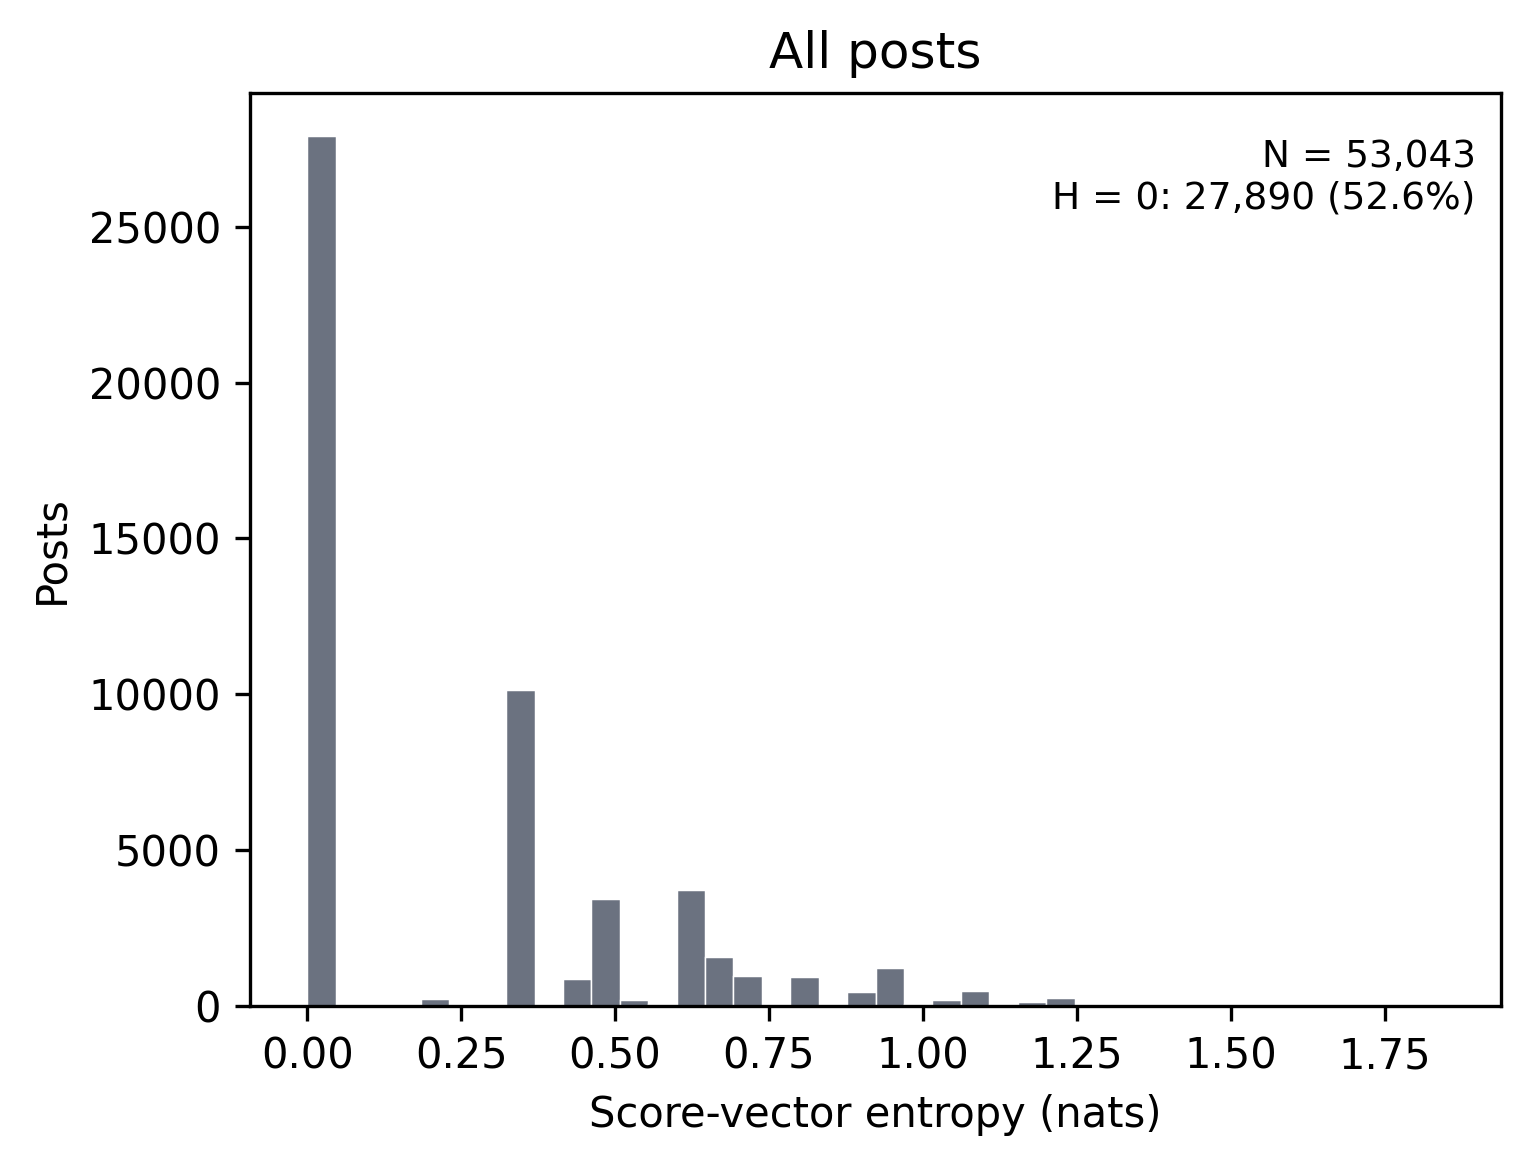

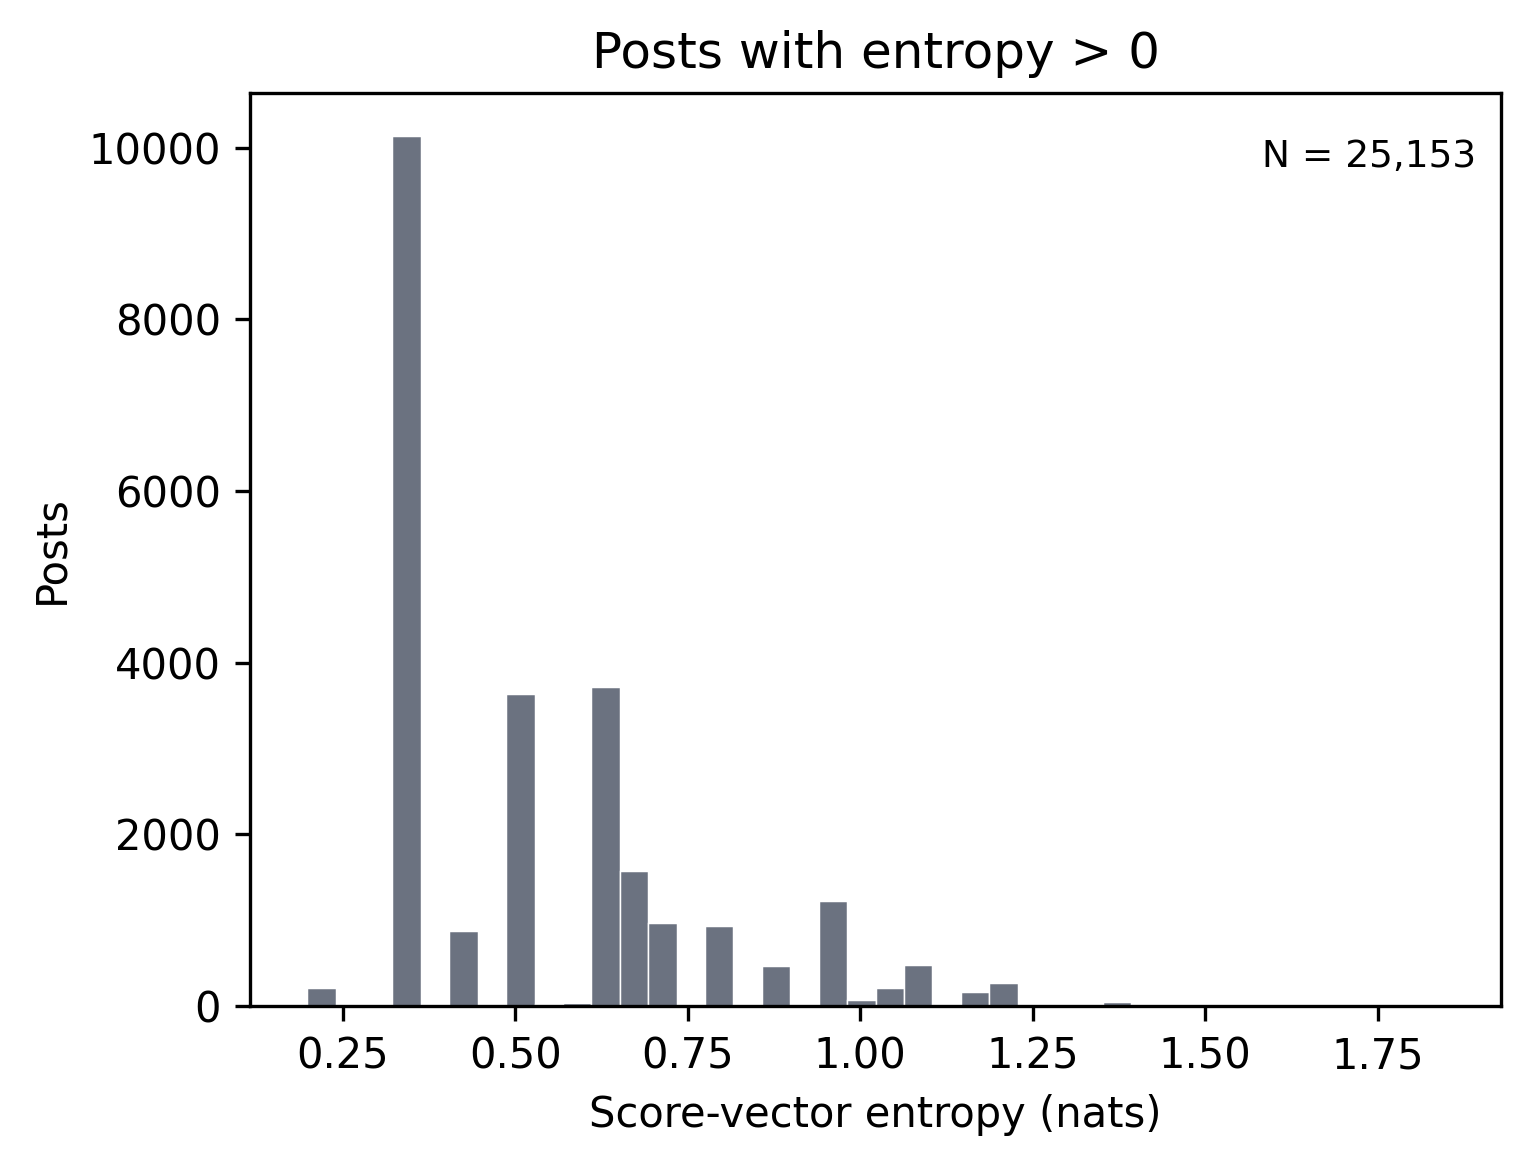

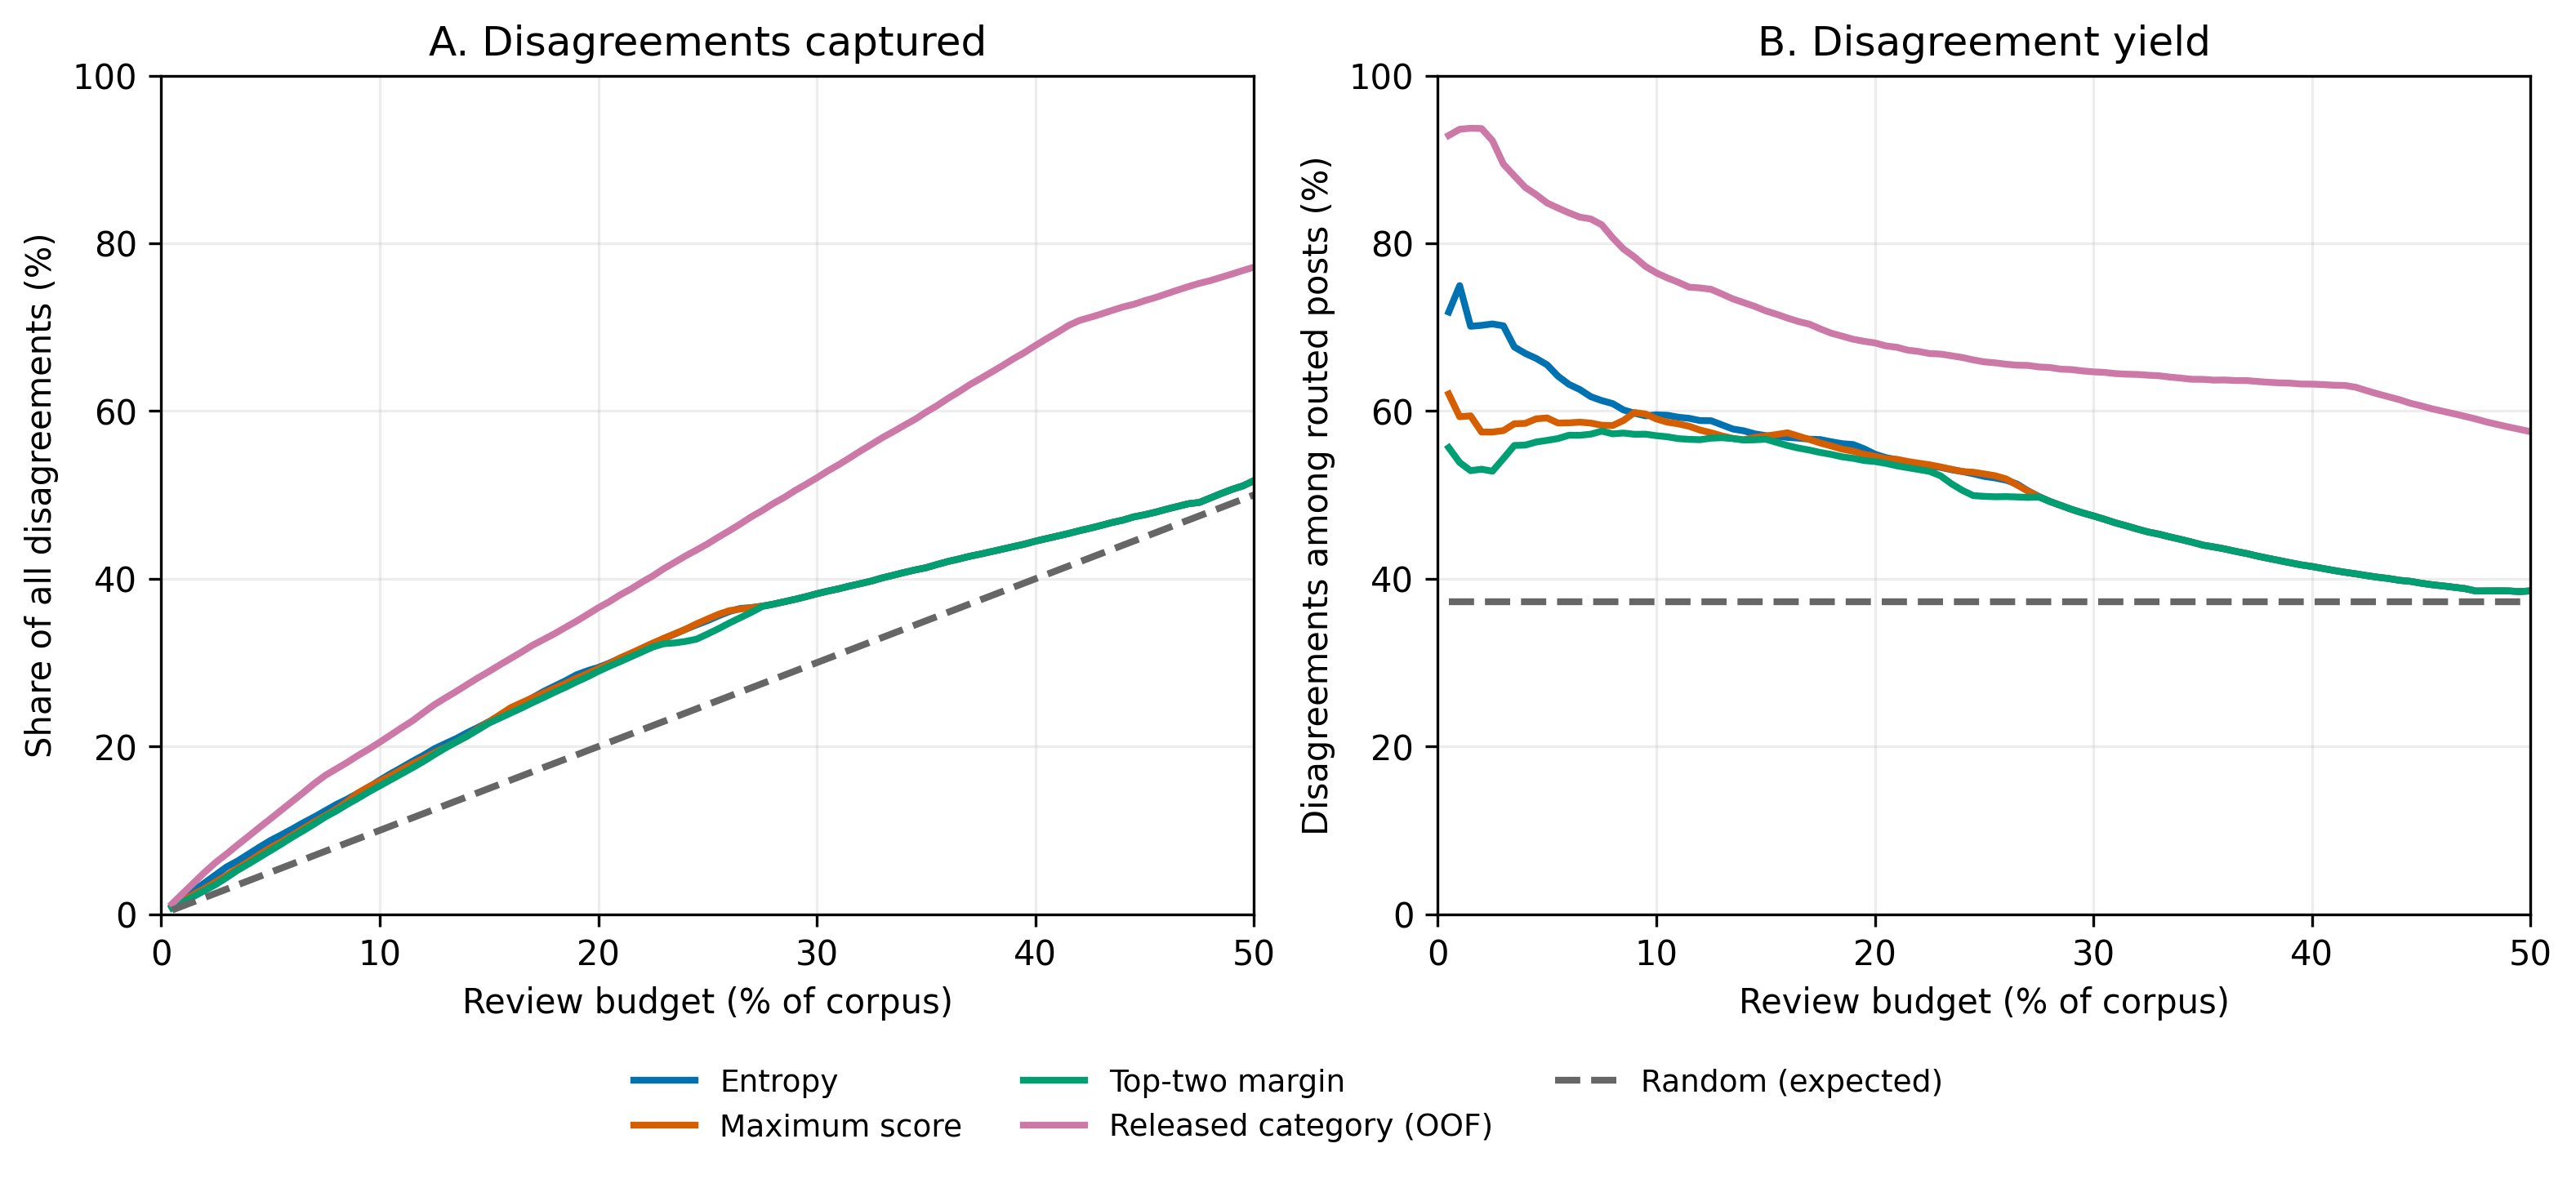

In [4]:
import pandas as pd
from IPython.display import Image, display

display(pd.read_csv(OUTPUT / 'entropy_strata_summary.csv'))
display(pd.read_csv(OUTPUT / 'routing_target_auroc.csv'))
display(pd.read_csv(OUTPUT / 'routing_review_budget_key_points.csv'))
display(Image(filename=str(OUTPUT / 'entropy_all.png')))
display(Image(filename=str(OUTPUT / 'entropy_pos.png')))
display(Image(filename=str(OUTPUT / 'routing_review_budget_curves.png')))